# Calibrating the Crowd — data tour

One-stop entry point to the datasets. Run top to bottom; every table is documented in `data/DATA_DICTIONARY.md`.

Core question: are prediction-market prices (Kalshi, Polymarket) as good as the de-vigged sportsbook consensus on the same games?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

core = pd.read_csv('../data/processed/analysis_core.csv')
print(core.shape)
core.head(3)

(10118, 16)


,game_id,league,start_utc,home_team,away_team,kalshi_home_prob,polymarket_home_prob,book_home_prob_devig,book_count,home_won,clean_set,book_home_prob_raw,book_away_prob_raw,book_home_prob_t24h,pinnacle_home_prob,betfair_home_prob
0,401766458,NBA,2025-04-15 23:30:00+00:00,Orlando Magic,Atlanta Hawks,0.6915,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN
1,401766459,NBA,2025-04-16 02:00:00+00:00,Golden State Warriors,Memphis Grizzlies,0.7178,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN
2,401695169,MLB,2025-04-16 17:07:00+00:00,Toronto Blue Jays,Atlanta Braves,0.4677,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN


## The headline: three venues, one Brier

`clean_set` filters to games passing all outcome cross-checks. The paper's three-way sample is the 5,328 games where all three venues priced.

In [2]:
t3 = core[core.clean_set & core.kalshi_home_prob.notna()
          & core.polymarket_home_prob.notna() & core.book_home_prob_devig.notna()]
for c in ['kalshi_home_prob','polymarket_home_prob','book_home_prob_devig','pinnacle_home_prob']:
    sub = t3[t3[c].notna()]
    print(f"{c:>26}: n={len(sub):,}  Brier={((sub[c]-sub.home_won)**2).mean():.4f}")

          kalshi_home_prob: n=5,333  Brier=0.2196
      polymarket_home_prob: n=5,333  Brier=0.2198
      book_home_prob_devig: n=5,333  Brier=0.2196
        pinnacle_home_prob: n=5,284  Brier=0.2207


## Table 1: do teams priced at X% win X% of the time?

In [3]:
bins = np.linspace(0, 1, 11)
for c, lab in [('kalshi_home_prob','Kalshi'), ('polymarket_home_prob','Polymarket'),
               ('book_home_prob_devig','Books')]:
    b = pd.cut(t3[c], bins)
    tab = t3.groupby(b, observed=True).agg(n=(c,'size'), priced=(c,'mean'), won=('home_won','mean'))
    print(f"\n=== {lab} ==="); print((tab*[1,100,100]).round(1).to_string())


=== Kalshi ===
                     n  priced   won
kalshi_home_prob                    
(0.0, 0.1]          51     7.0   5.9
(0.1, 0.2]         157    15.9  19.1
(0.2, 0.3]         231    25.3  22.5
(0.3, 0.4]         455    35.7  41.5
(0.4, 0.5]        1105    45.6  46.5
(0.5, 0.6]        1533    55.2  54.5
(0.6, 0.7]         868    64.3  64.2
(0.7, 0.8]         468    74.8  73.3
(0.8, 0.9]         323    85.0  83.3
(0.9, 1.0]         142    93.7  99.3

=== Polymarket ===
                         n  priced   won
polymarket_home_prob                    
(0.0, 0.1]              51     7.0   5.9
(0.1, 0.2]             161    16.0  19.3
(0.2, 0.3]             224    25.3  22.8
(0.3, 0.4]             457    35.7  40.0
(0.4, 0.5]            1101    45.6  47.3
(0.5, 0.6]            1537    55.1  54.4
(0.6, 0.7]             878    64.3  64.0
(0.7, 0.8]             461    74.8  73.3
(0.8, 0.9]             319    85.0  83.4
(0.9, 1.0]             144    93.6  98.6

=== Books ===
             

## Calibration picture (both sides stacked)

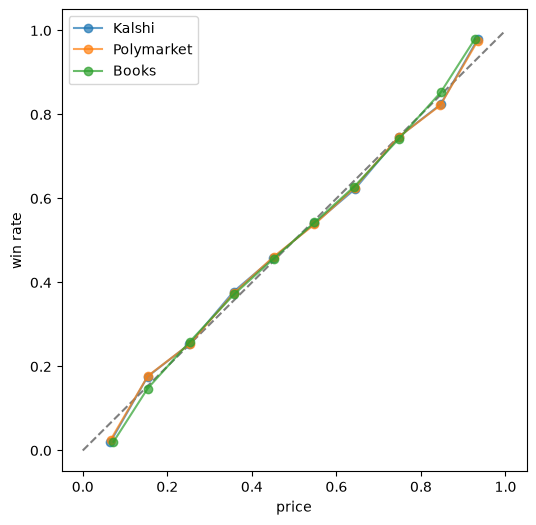

In [4]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],'k--',alpha=.5)
for c, lab in [('kalshi_home_prob','Kalshi'),('polymarket_home_prob','Polymarket'),('book_home_prob_devig','Books')]:
    p = np.r_[t3[c], 1-t3[c]]; w = np.r_[t3.home_won, 1-t3.home_won]
    b = np.clip(np.digitize(p, bins)-1, 0, 9)
    xs=[p[b==k].mean() for k in range(10)]; ys=[w[b==k].mean() for k in range(10)]
    ax.plot(xs, ys, 'o-', label=lab, alpha=.7)
ax.set(xlabel='price', ylabel='win rate'); ax.legend(); plt.show()

## Other tables to explore

- `sportsbook_sharp_prices.csv` — 24 books per game incl. Pinnacle and Betfair Exchange (per-book quotes; de-vig with `p1/(p1+p2)`)
- `kalshi_trades_24h.csv` — 710K individual fills (who trades, when, what size)
- `kalshi_spread_prices.csv` + `sportsbook_alt_spreads.csv` — margin-of-victory ladders, both venues
- `kalshi_futures_prices.csv` + `sportsbook_outrights.csv` + `poly_futures_prices.csv` — the futures 2x2 (where calibration breaks)
- `kalshi_niche_prices.csv` — table tennis / cricket / esports / minor soccer (calibration without a benchmark)

Every number in the paper regenerates with `python -m src.make_results` (52 modules, audit-gated).

In [5]:
trades = pd.read_csv('../data/processed/kalshi_trades_24h.csv')
print(f"{len(trades):,} fills, median {trades['count'].median():.0f} contracts "
      f"(~${(np.where(trades.taker_side=='yes',trades.yes_price,1-trades.yes_price)*trades['count']).mean():.0f} avg stake)")

710,129 fills, median 30 contracts (~$135 avg stake)
